In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from io import StringIO

# Pastel colour palette
P = {
    'code1':   '#F4A8A8',  # soft rose   — passive receipt
    'code2':   '#F9D49B',  # soft amber  — surface engagement
    'code3':   '#A8D5A2',  # soft green  — active interrogation
    'blue':    '#A8C4E0',  # soft blue   — primary grouped bars
    'orange':  '#F9C49B',  # soft peach  — secondary grouped bars
    'sage':    '#B5C9A8',  # sage green  — no SEN
    'grey':    '#C8C8C8',  # light grey  — honest low
    'lblue':   '#D6E8F5',  # light blue  — other category
    'red_line':'#E07070',  # muted red   — reference lines
}

raw = """student_id,session,school,year_group,subject,task_type,sen_flag,sen_type,used_ai_or_copied,agency_code,q1_ownership,q2_explainability,notes
S001,1,school_b,7,computing,problem_solving,0,none,Y,2,2,1,"Reread answer, changed subject-specific vocabulary"
S002,1,school_b,7,maths,calculation,0,none,N,3,2,1,No AI used — textbook only
S003,1,school_b,8,science,explain_concept,1,dyslexia,N,1,2,1,Used notes from class
S004,1,school_b,10,computing,problem_solving,1,autism,Y,2,2,0,Compared two AI responses briefly before choosing one
S005,1,school_a,7,computing,problem_solving,1,adhd,Y,3,2,2,"Questioned AI answer verbally, looked for second source"
S006,1,school_a,7,computing,explain_concept,0,none,Y,2,0,1,"Reread answer, changed subject-specific vocabulary"
S007,1,school_a,8,maths,calculation,1,autism,Y,1,1,0,"Opened ChatGPT, typed question, copied answer verbatim"
S008,1,school_a,8,maths,calculation,0,none,Y,1,1,0,No visible engagement with output before writing
S009,1,school_a,8,science,definition_question,0,none,N,1,0,0,"Asked peer for help, no AI"
S010,1,school_a,8,science,definition_question,0,none,Y,3,2,2,Identified error in AI output independently
S011,1,school_a,9,science,definition_question,1,autism,Y,1,1,0,"Did not check answer, submitted immediately"
S012,1,school_a,9,maths,calculation,0,none,Y,2,2,1,"Reread answer, changed subject-specific vocabulary"
S013,1,school_a,9,computing,explain_concept,1,dyslexia,Y,1,2,0,"Did not check answer, submitted immediately"
S014,1,school_a,11,computing,problem_solving,0,none,Y,1,2,1,Copied from phone directly
S015,2,school_b,7,computing,problem_solving,1,adhd,Y,1,0,2,"Opened ChatGPT, typed question, copied answer verbatim"
S016,2,school_b,7,maths,problem_solving,1,dyslexia_adhd,Y,2,1,1,Made minor edits to AI output
S017,2,school_b,7,science,calculation,1,autism_adhd,Y,3,2,2,Asked observer if AI answer was correct before writing
S018,2,school_b,8,maths,short_answer,0,none,N,1,0,0,No AI observed — worked independently
S019,2,school_a,7,maths,calculation,1,autism_adhd,?,1,2,1,"Looked at screen briefly, wrote without pausing"
S020,2,school_a,7,computing,explain_concept,1,autism_adhd,Y,3,2,2,Rewrote answer entirely in own words after reading AI output
S021,2,school_a,7,maths,short_answer,0,none,N,1,0,1,Used notes from class
S022,2,school_a,8,science,explain_concept,0,none,Y,1,2,0,"Looked at screen briefly, wrote without pausing"
S023,2,school_a,8,maths,problem_solving,1,adhd,N,2,1,2,Used notes from class
S024,2,school_a,8,science,explain_concept,1,dyslexia,N,1,0,1,No AI observed — worked independently
S025,2,school_a,9,computing,definition_question,0,none,Y,3,2,0,Identified error in AI output independently
S026,2,school_a,9,computing,problem_solving,1,autism_adhd,Y,2,1,1,Paused and reread before writing
S027,2,school_a,10,maths,calculation,0,none,Y,1,2,1,Copied from phone directly
S028,2,school_a,10,science,short_answer,1,dyslexia,Y,3,1,2,"Used AI as starting point, significantly expanded and modified"
S029,2,school_a,11,business,definition_question,1,dyslexia_adhd,Y,2,1,1,"Paused mid-copy, re-read, continued"
S030,3,school_b,7,maths,problem_solving,1,dyslexia,Y,3,2,2,Rewrote answer entirely in own words after reading AI output
S031,3,school_b,7,science,calculation,0,none,Y,1,1,1,"Shared AI answer with peer, both copied"
S032,3,school_b,7,maths,short_answer,0,none,Y,1,2,0,Copied from phone directly
S033,3,school_b,8,science,short_answer,0,none,N,1,2,1,"Asked peer for help, no AI"
S034,3,school_b,10,science,definition_question,0,none,N,1,1,1,No AI observed — worked independently
S035,3,school_b,10,maths,calculation,0,none,Y,2,0,1,"Reread answer, changed subject-specific vocabulary"
S036,3,school_a,8,maths,calculation,1,autism_adhd,Y,3,2,2,Asked peer to check AI answer before submitting
S037,3,school_a,8,computing,explain_concept,1,autism,Y,3,2,2,Rewrote answer entirely in own words after reading AI output
S038,3,school_a,8,science,definition_question,1,dyslexia,N,1,0,0,No AI observed — worked independently
S039,3,school_a,8,maths,problem_solving,0,none,?,2,2,1,"Reread answer, changed subject-specific vocabulary"
S040,3,school_a,10,science,calculation,0,none,Y,2,1,1,Compared two AI responses briefly before choosing one
S041,3,school_a,11,computing,problem_solving,1,adhd,Y,2,0,2,Paused and reread before writing
S042,4,school_b,7,science,definition_question,1,dyslexia,N,2,0,0,Used notes from class
S043,4,school_b,7,computing,definition_question,0,none,Y,2,1,2,Paused and reread before writing
S044,4,school_b,9,computing,problem_solving,0,none,Y,2,2,1,"Looked uncertain, re-read twice before writing"
S045,4,school_b,9,maths,calculation,0,none,N,2,1,1,No AI used — textbook only
S046,4,school_b,11,science,explain_concept,1,autism_adhd,Y,2,2,2,"Reread answer, changed subject-specific vocabulary"
S047,4,school_a,7,maths,problem_solving,1,autism,N,3,1,2,Used notes from class
S048,4,school_a,7,maths,calculation,0,none,N,1,1,2,"Asked peer for help, no AI"
S049,4,school_a,8,computing,explain_concept,0,none,Y,1,1,1,Used Google then copied first result
S050,4,school_a,8,maths,problem_solving,0,none,N,1,2,0,No AI used — textbook only
S051,4,school_a,8,science,explain_concept,1,autism,N,1,2,0,No AI observed — worked independently
S052,4,school_a,8,computing,definition_question,0,none,Y,1,2,2,Used Google then copied first result
S053,4,school_a,9,computing,short_answer,0,none,N,3,2,2,No AI used — textbook only
S054,4,school_a,10,science,short_answer,1,autism,Y,2,0,1,"Reread answer, changed subject-specific vocabulary"
S055,4,school_a,10,science,short_answer,0,none,N,1,2,1,No AI used — textbook only
S056,4,school_a,10,maths,short_answer,1,dyslexia,N,3,1,2,Used notes from class
S057,4,school_a,10,computing,problem_solving,1,adhd,N,1,2,0,Used notes from class
S058,4,school_a,11,business,definition_question,0,none,Y,2,2,2,Changed a few words in AI answer before submitting
S059,5,school_b,8,maths,problem_solving,1,adhd,Y,1,1,0,"Shared AI answer with peer, both copied"
S060,5,school_b,9,maths,calculation,1,adhd,N,2,1,1,No AI used — textbook only
S061,5,school_b,9,computing,problem_solving,1,dyslexia_adhd,Y,2,1,1,Changed a few words in AI answer before submitting
S062,5,school_b,10,business,definition_question,0,none,N,1,1,1,Used notes from class
S063,5,school_a,7,maths,short_answer,1,adhd,N,1,0,2,"Asked peer for help, no AI"
S064,5,school_a,8,maths,problem_solving,1,autism,Y,1,0,1,"Shared AI answer with peer, both copied"
S065,5,school_a,8,maths,calculation,1,autism,N,2,2,1,"Asked peer for help, no AI"
S066,5,school_a,8,science,short_answer,1,autism_adhd,N,1,2,0,No AI used — textbook only
S067,5,school_a,9,maths,short_answer,1,dyslexia,Y,1,2,1,Used Google then copied first result
S068,5,school_a,9,computing,explain_concept,1,adhd,N,1,1,0,Used notes from class
S069,5,school_a,9,computing,definition_question,0,none,Y,2,2,1,Changed a few words in AI answer before submitting
S070,5,school_a,9,science,short_answer,1,autism,Y,3,1,1,"Compared AI answer to textbook, noted discrepancy"
S071,5,school_a,9,computing,definition_question,0,none,Y,3,2,2,"Questioned AI answer verbally, looked for second source"
S072,5,school_a,10,computing,problem_solving,0,none,N,2,1,1,No AI observed — worked independently
S073,5,school_a,10,computing,short_answer,1,autism_adhd,N,1,0,0,No AI observed — worked independently"""

df = pd.read_csv(StringIO(raw))
print(f"N = {len(df)} students across {df.session.nunique()} sessions")
print(f"Schools: {list(df.school.unique())}")
print(f"Year groups: {sorted(df.year_group.unique())}")
print(f"SEN students: {df.sen_flag.sum()} ({df.sen_flag.mean()*100:.0f}%)")
print(f"\nSubjects by year group:")
print(df.groupby(['year_group','subject']).size().unstack(fill_value=0).to_string())
df.head()

N = 73 students across 5 sessions
Schools: ['school_b', 'school_a']
Year groups: [np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
SEN students: 39 (53%)

Subjects by year group:
subject     business  computing  maths  science
year_group                                     
7                  0          6      9        3
8                  0          3     10        9
9                  0          9      4        2
10                 1          4      3        5
11                 2          2      0        1


,student_id,session,school,year_group,subject,task_type,sen_flag,sen_type,used_ai_or_copied,agency_code,q1_ownership,q2_explainability,notes
0,S001,1,school_b,7,computing,problem_solving,0,none,Y,2,2,1,"Reread answer, changed subject-specific vocabu..."
1,S002,1,school_b,7,maths,calculation,0,none,N,3,2,1,No AI used — textbook only
2,S003,1,school_b,8,science,explain_concept,1,dyslexia,N,1,2,1,Used notes from class
3,S004,1,school_b,10,computing,problem_solving,1,autism,Y,2,2,0,Compared two AI responses briefly before choos...
4,S005,1,school_a,7,computing,problem_solving,1,adhd,Y,3,2,2,"Questioned AI answer verbally, looked for seco..."


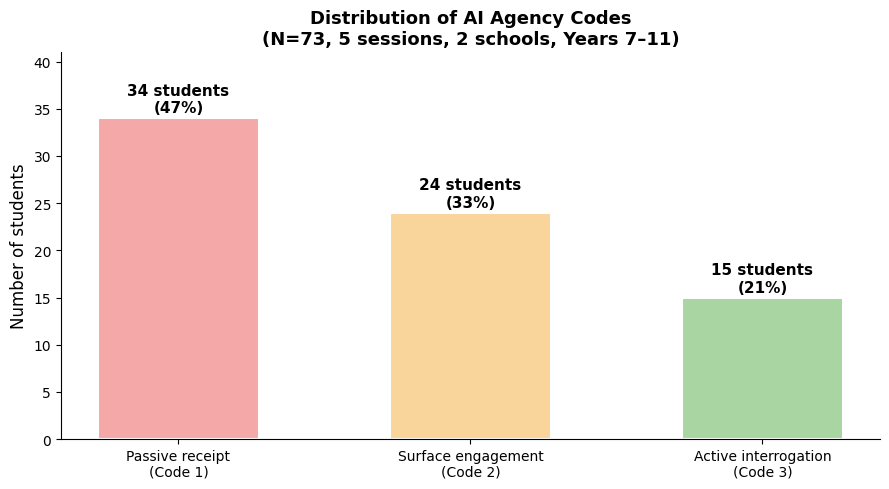

In [6]:
labels = ['Passive receipt\n(Code 1)', 'Surface engagement\n(Code 2)', 'Active interrogation\n(Code 3)']
counts = df['agency_code'].value_counts().sort_index()
pcts = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, counts.values,
              color=[P['code1'], P['code2'], P['code3']],
              edgecolor='white', linewidth=1.5, width=0.55)
for bar, pct, count in zip(bars, pcts, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{count} students\n({pct:.0f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of students', fontsize=12)
ax.set_title('Distribution of AI Agency Codes\n(N=73, 5 sessions, 2 schools, Years 7–11)', fontsize=13, fontweight='bold')
ax.set_ylim(0, counts.max()+7)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('agency_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

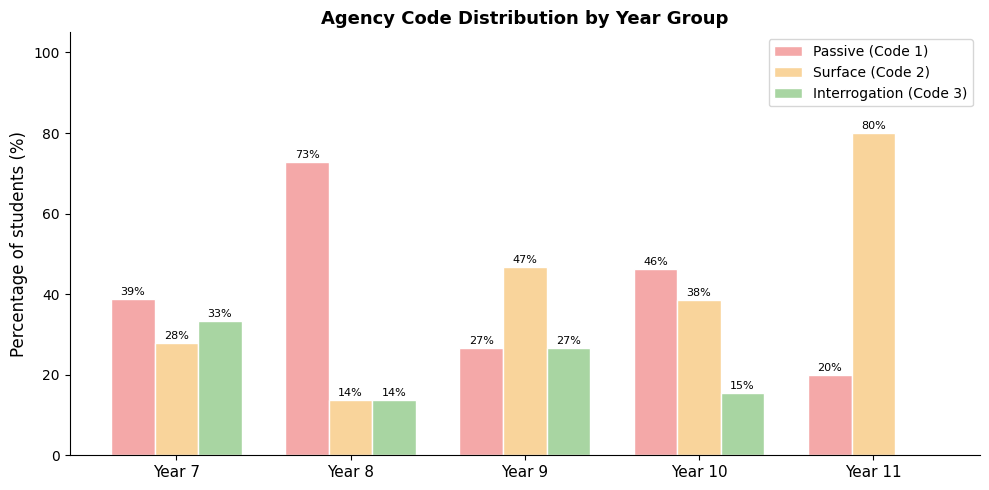

In [7]:
pivot = df.groupby(['year_group','agency_code']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(pivot_pct))
w = 0.25
labels_a = ['Passive (Code 1)', 'Surface (Code 2)', 'Interrogation (Code 3)']

for i, (col, color, label) in enumerate(zip([1,2,3], [P['code1'],P['code2'],P['code3']], labels_a)):
    if col in pivot_pct.columns:
        vals = pivot_pct[col].values
        bars = ax.bar(x + i*w, vals, w, label=label, color=color, edgecolor='white')
        for bar, val in zip(bars, vals):
            if val > 5:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                        f'{val:.0f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + w)
ax.set_xticklabels([f'Year {y}' for y in pivot_pct.index], fontsize=11)
ax.set_ylabel('Percentage of students (%)', fontsize=12)
ax.set_title('Agency Code Distribution by Year Group', fontsize=13, fontweight='bold')
ax.set_ylim(0, 105)
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('agency_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

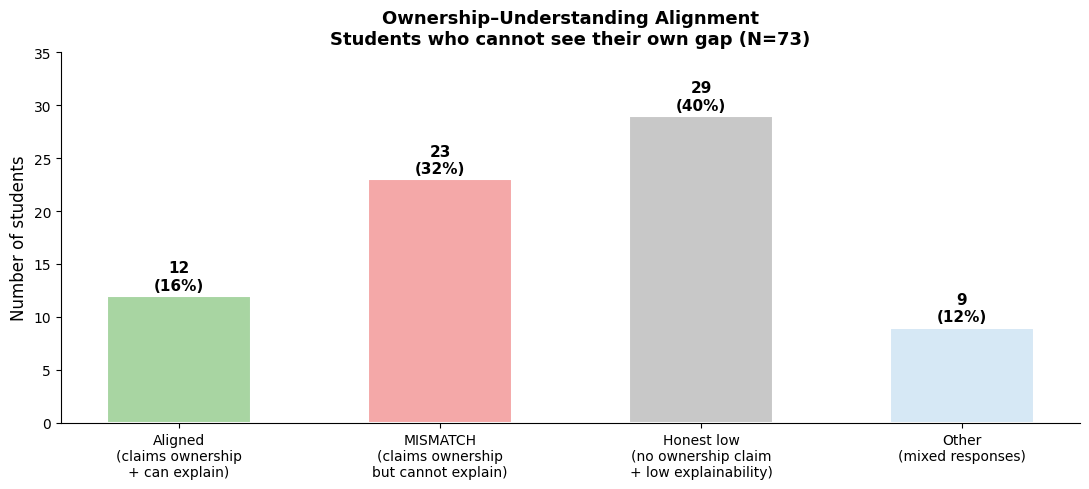

Mismatch group: n=23 (32%)
Their agency codes: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3]

Mismatch by year group:
year_group
7     4
8     8
9     6
10    4
11    1


In [8]:
mismatch     = df[(df['q1_ownership']==2) & (df['q2_explainability']<=1)]
aligned_high = df[(df['q1_ownership']==2) & (df['q2_explainability']==2)]
honest_low   = df[(df['q1_ownership']<=1) & (df['q2_explainability']<=1)]
other        = len(df) - len(mismatch) - len(aligned_high) - len(honest_low)

categories = ['Aligned\n(claims ownership\n+ can explain)',
              'MISMATCH\n(claims ownership\nbut cannot explain)',
              'Honest low\n(no ownership claim\n+ low explainability)',
              'Other\n(mixed responses)']
values = [len(aligned_high), len(mismatch), len(honest_low), other]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(categories, values,
              color=[P['code3'], P['code1'], P['grey'], P['lblue']],
              edgecolor='white', linewidth=1.5, width=0.55)
for bar, val in zip(bars, values):
    pct = val/len(df)*100
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val}\n({pct:.0f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of students', fontsize=12)
ax.set_title('Ownership–Understanding Alignment\nStudents who cannot see their own gap (N=73)', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(values)+6)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('mismatch_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mismatch group: n={len(mismatch)} ({len(mismatch)/len(df)*100:.0f}%)")
print(f"Their agency codes: {sorted(mismatch.agency_code.tolist())}")
print(f"\nMismatch by year group:")
print(mismatch.groupby('year_group').size().to_string())

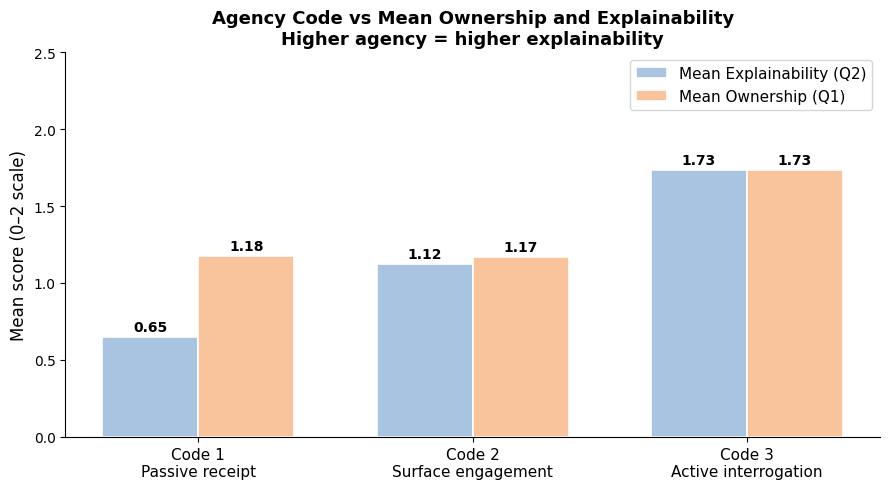

In [9]:
agency_explain = df.groupby('agency_code')['q2_explainability'].mean()
agency_own     = df.groupby('agency_code')['q1_ownership'].mean()

x = np.array([1,2,3])
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x-w/2, agency_explain.values, w, label='Mean Explainability (Q2)',
            color=P['blue'], edgecolor='white', linewidth=1.2)
b2 = ax.bar(x+w/2, agency_own.values, w, label='Mean Ownership (Q1)',
            color=P['orange'], edgecolor='white', linewidth=1.2)
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Code 1\nPassive receipt', 'Code 2\nSurface engagement', 'Code 3\nActive interrogation'], fontsize=11)
ax.set_ylabel('Mean score (0–2 scale)', fontsize=12)
ax.set_title('Agency Code vs Mean Ownership and Explainability\nHigher agency = higher explainability', fontsize=13, fontweight='bold')
ax.set_ylim(0, 2.5)
ax.legend(fontsize=11)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('agency_vs_scores.png', dpi=150, bbox_inches='tight')
plt.show()

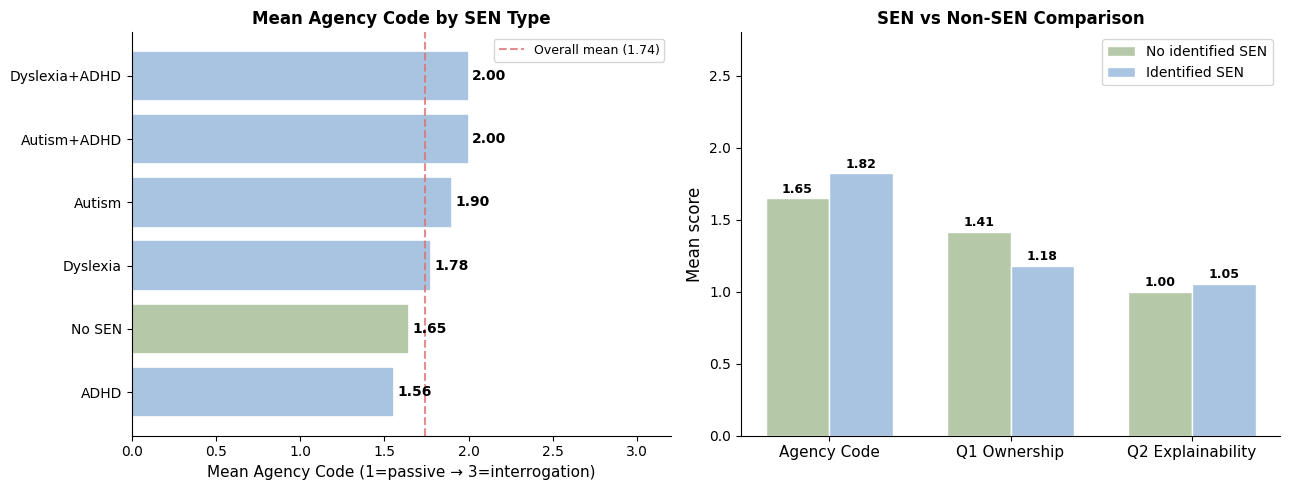

In [10]:
sen_labels = {
    'none': 'No SEN', 'autism': 'Autism', 'adhd': 'ADHD',
    'dyslexia': 'Dyslexia', 'autism_adhd': 'Autism+ADHD',
    'dyslexia_adhd': 'Dyslexia+ADHD', 'other_neurological': 'Other'
}

sen_agency = df.groupby('sen_type')['agency_code'].mean().sort_values()
sen_agency.index = [sen_labels.get(i,i) for i in sen_agency.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: mean agency by SEN type
colors_bar = [P['sage'] if i == 'No SEN' else P['blue'] for i in sen_agency.index]
bars = axes[0].barh(sen_agency.index, sen_agency.values,
                    color=colors_bar, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, sen_agency.values):
    axes[0].text(val+0.02, bar.get_y()+bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Mean Agency Code (1=passive → 3=interrogation)', fontsize=11)
axes[0].set_title('Mean Agency Code by SEN Type', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, 3.2)
axes[0].axvline(x=df['agency_code'].mean(), color=P['red_line'], linestyle='--', alpha=0.8,
                label=f'Overall mean ({df.agency_code.mean():.2f})')
axes[0].legend(fontsize=9)
axes[0].spines[['top','right']].set_visible(False)

# Right: SEN vs non-SEN
measures = ['agency_code', 'q1_ownership', 'q2_explainability']
measure_labels = ['Agency Code', 'Q1 Ownership', 'Q2 Explainability']
x_pos = np.arange(len(measures))
w2 = 0.35
sen_means   = [df[df.sen_flag==1][m].mean() for m in measures]
nosen_means = [df[df.sen_flag==0][m].mean() for m in measures]

b1 = axes[1].bar(x_pos-w2/2, nosen_means, w2, label='No identified SEN',
                 color=P['sage'], edgecolor='white')
b2 = axes[1].bar(x_pos+w2/2, sen_means, w2, label='Identified SEN',
                 color=P['blue'], edgecolor='white')
for bar in list(b1)+list(b2):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(measure_labels, fontsize=11)
axes[1].set_ylabel('Mean score', fontsize=12)
axes[1].set_title('SEN vs Non-SEN Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 2.8)
axes[1].legend(fontsize=10)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('sen_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

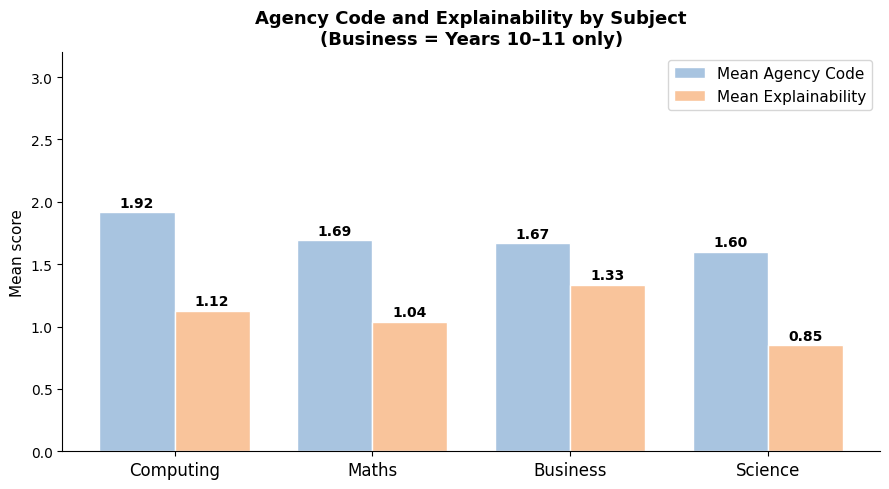

In [11]:
subj_agency  = df.groupby('subject')['agency_code'].mean().sort_values(ascending=False)
subj_explain = df.groupby('subject')['q2_explainability'].mean()

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(subj_agency))
w = 0.38
b1 = ax.bar(x-w/2, subj_agency.values, w, label='Mean Agency Code',
            color=P['blue'], edgecolor='white')
b2 = ax.bar(x+w/2, [subj_explain[s] for s in subj_agency.index], w,
            label='Mean Explainability', color=P['orange'], edgecolor='white')
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([s.capitalize() for s in subj_agency.index], fontsize=12)
ax.set_ylabel('Mean score', fontsize=11)
ax.set_title('Agency Code and Explainability by Subject\n(Business = Years 10–11 only)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 3.2)
ax.legend(fontsize=11)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('subject_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
mismatch = df[(df['q1_ownership']==2) & (df['q2_explainability']<=1)]

print("=" * 55)
print("  PILOT STUDY — SUMMARY OF FINDINGS")
print("=" * 55)
print(f"\nN = {len(df)} | {df.session.nunique()} sessions | 2 schools")
print(f"Year groups: 7-11 | SEN: {df.sen_flag.sum()} ({df.sen_flag.mean()*100:.0f}%)")

print("\n--- Agency Distribution ---")
for code, label in {1:'Passive receipt', 2:'Surface engagement', 3:'Active interrogation'}.items():
    n = (df.agency_code==code).sum()
    print(f"  {label} (code {code}): n={n} ({n/len(df)*100:.0f}%)")

print("\n--- Key Finding: Mismatch ---")
print(f"  Claims ownership but cannot explain: n={len(mismatch)} ({len(mismatch)/len(df)*100:.0f}%)")
print(f"  Predominantly passive (code 1): {(mismatch.agency_code==1).sum()} of {len(mismatch)}")

print("\n--- Mean Explainability by Agency Code ---")
for code in [1,2,3]:
    m = df[df.agency_code==code]['q2_explainability'].mean()
    print(f"  Code {code}: {m:.2f}")

print("\n--- By Subject ---")
print(df.groupby('subject')[['agency_code','q2_explainability']].mean().round(2).to_string())

print("\n--- By SEN Status ---")
print(df.groupby('sen_flag')[['agency_code','q1_ownership','q2_explainability']].mean().round(2).to_string())

print("\n--- Limitations ---")
print("  Naturalistic observation — no intervention")
print("  Single observer — subjective coding possible")
print("  Sample from one TA's classrooms — not representative")
print("  No formal ethics review — non-interventional study")
print("  Results are descriptive only")
print("=" * 55)

  PILOT STUDY — SUMMARY OF FINDINGS

N = 73 | 5 sessions | 2 schools
Year groups: 7-11 | SEN: 39 (53%)

--- Agency Distribution ---
  Passive receipt (code 1): n=34 (47%)
  Surface engagement (code 2): n=24 (33%)
  Active interrogation (code 3): n=15 (21%)

--- Key Finding: Mismatch ---
  Claims ownership but cannot explain: n=23 (32%)
  Predominantly passive (code 1): 14 of 23

--- Mean Explainability by Agency Code ---
  Code 1: 0.65
  Code 2: 1.12
  Code 3: 1.73

--- By Subject ---
           agency_code  q2_explainability
subject                                  
business          1.67               1.33
computing         1.92               1.12
maths             1.69               1.04
science           1.60               0.85

--- By SEN Status ---
          agency_code  q1_ownership  q2_explainability
sen_flag                                              
0                1.65          1.41               1.00
1                1.82          1.18               1.05

--- Limitation